### Mar 11 quadratic zeeman

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [39]:
freq = 2.5
savename = "10s measurement Mar 16 - 2p5MHz"
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 16 measurement/2p5MHz_10s.csv')

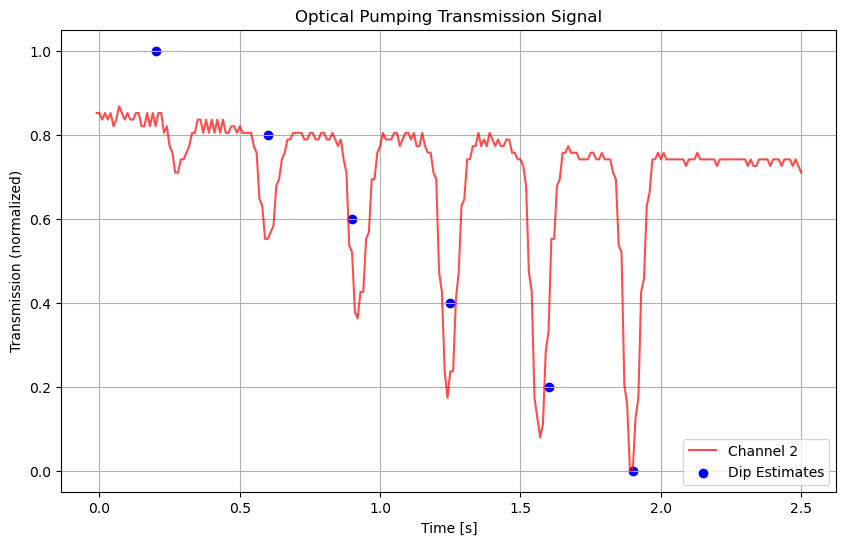

In [46]:
t0 = 3.5
tf = 6
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([0.2,0.6,0.9,1.25,1.6,1.9])

m.plot_quadraticZeeman_sextuple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [47]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4",  "h5", "g5", "x0_5",  "h6", "g6", "x0_6"]
p0 = (1, -0.02, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3], 0.5, 0.1, x0s[4], 0.5, 0.1, x0s[5])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.sextuple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 1.2769655822253563
m -0.2046583479123607
h1 0.42291704445117295
g1 0.8489984998702541
x0_1 0.11625969047965161
h2 0.2951595277523475
g2 0.02970188472191049
x0_2 0.6029298578219018
h3 0.4953825550376635
g3 0.03504657735535287
x0_3 0.9235670202175947
h4 0.6965289570169712
g4 0.032634726900889276
x0_4 1.2453731843257718
h5 0.7914698851624514
g5 0.03190513428151285
x0_5 1.569753692238913
h6 0.8453406924526315
g6 0.030048474177982155
x0_6 1.8966717451992714


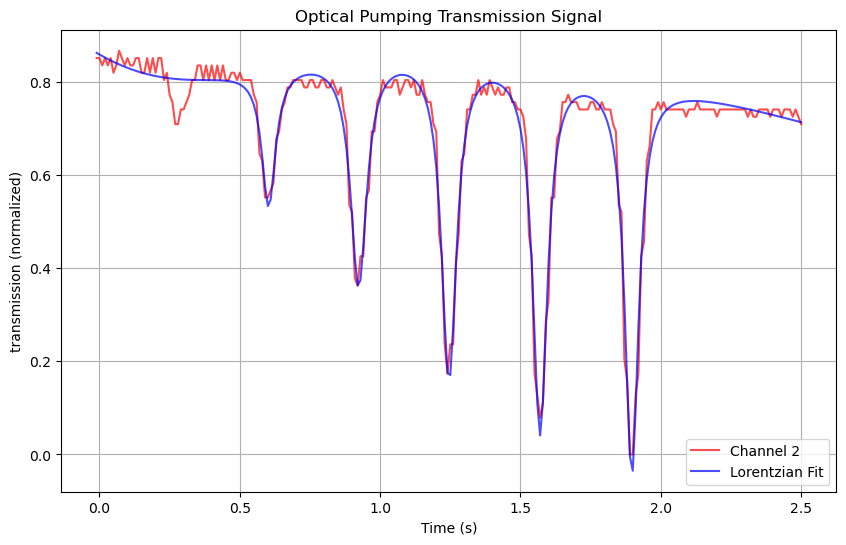

In [48]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.sextuple_lorentz, "fit to " + savename)


In [49]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0
x0_5_u = ufloat(popt[16], perr[16]) + t0
x0_6_u = ufloat(popt[19], perr[19]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)
x0_5_index = int(x0_5_u.n // dt)
x0_6_index = int(x0_6_u.n // dt)

numAvg = 10


vMeasured =0.3045  # V
vShift = ufloat(vMeasured,0.002 * vMeasured) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(3.012,0.031) # taken from 195kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]) / np.sqrt(2*numAvg))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]) / np.sqrt(2*numAvg))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]) / np.sqrt(2*numAvg))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]) / np.sqrt(2*numAvg))
v_5 = ufloat(np.mean(y1[x0_5_index - numAvg : x0_5_index + numAvg]),
             np.std(y1[x0_5_index - numAvg : x0_5_index + numAvg]) / np.sqrt(2*numAvg))
v_6 = ufloat(np.mean(y1[x0_6_index - numAvg : x0_6_index + numAvg]),
             np.std(y1[x0_6_index - numAvg : x0_6_index + numAvg]) / np.sqrt(2*numAvg))

VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100)
VtoBHoriz = ufloat(2*8.8*10**(-4),2*8.8*10**(-4) / 100)

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip5 = (v_5-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip6 = (v_6-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")
print(f"B field of dip 5: {dip5:.3e}")
print(f"B field of dip 6: {dip6:.3e}")

B field of dip 1: (3.808+/-0.060)e-04
B field of dip 2: (3.822+/-0.060)e-04
B field of dip 3: (3.830+/-0.060)e-04
B field of dip 4: (3.838+/-0.060)e-04
B field of dip 5: (3.847+/-0.060)e-04
B field of dip 6: (3.856+/-0.060)e-04


In [50]:
filepath = 'models/quadraticRb85ZeemanData.csv'

m.append_to_sextupleZeeman_csv(freq, (dip1,dip2,dip3,dip4,dip5,dip6), filepath)

In [52]:
freq = 3.7
savename = "10s measurement Mar 16 - 3p7MHz"
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 16 measurement/3p7MHz_10s.csv')

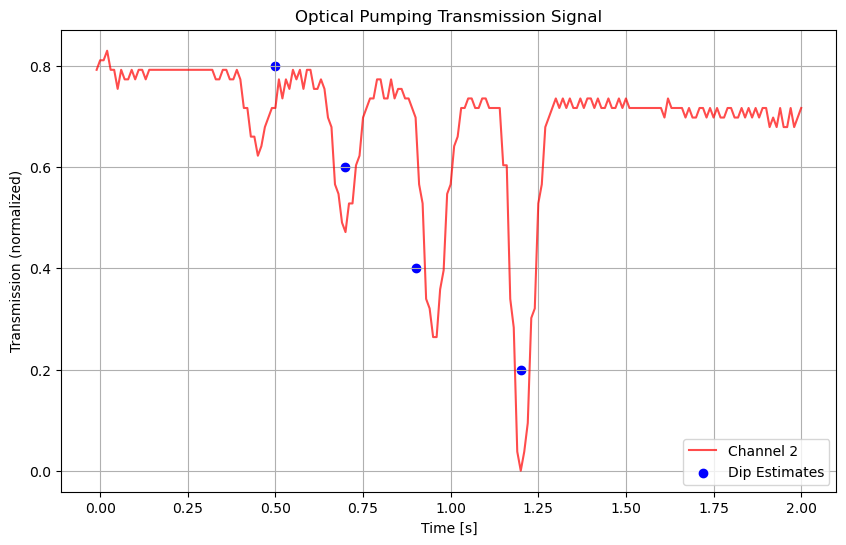

In [55]:
t0 = 3
tf = 5
nCutBeginning = (t0 // (time[1] - time[0])).astype(int)
nCutEnd = ((time[-1] - tf) // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCutBeginning:len(time)-nCutEnd] - t0
y2_norm_cutFirst = y2_norm[nCutBeginning:len(time)-nCutEnd]

x0s = np.array([0.5,0.7,0.9,1.2])

m.plot_quadraticZeeman_quadruple_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [56]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "m", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3",  "h4", "g4", "x0_4"]
p0 = (1, -0.02, 1, 0.1, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2], 0.5, 0.1, x0s[3])
lower_bound = (0,-1,0,0,0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,0,2,2,10,2,2,10,2,2,10,2,2,10)

# print(len(p0))
# print(len(variables))
# print(len(lower_bound))
# print(len(upper_bound))

bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.quadruple_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.8181700904188077
m -0.05456728585273445
h1 0.16318407193943427
g1 0.027941206913827857
x0_1 0.45058356273717654
h2 0.3129542530339809
g2 0.027353710231895798
x0_2 0.6991204793231484
h3 0.5345620096886358
g3 0.027898869477446013
x0_3 0.9532388506197302
h4 0.8051167671847703
g4 0.027286824924286277
x0_4 1.2046163404015477


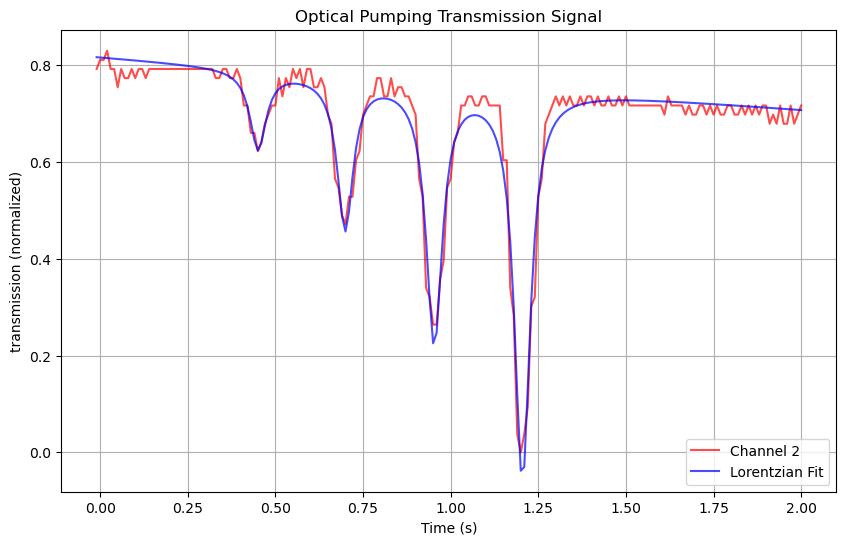

In [57]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, m.quadruple_lorentz, "fit to " + savename)


In [58]:
x0_1_u = ufloat(popt[4],  perr[4]) + t0
x0_2_u = ufloat(popt[7],  perr[7]) + t0
x0_3_u = ufloat(popt[10], perr[10]) + t0
x0_4_u = ufloat(popt[13], perr[13]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)
x0_4_index = int(x0_4_u.n // dt)

numAvg = 10


vMeasured = 0.302  # V
vShift = ufloat(vMeasured,0.002 * vMeasured) # range shifted, either get from data or write down dial position idk
# TODO: adjust this, I assumed 0.2% ucnertainty from seeing how much the smaller digits varied at a constant measurement

v_0Field = ufloat(3.012,0.031) # taken from 195kHz, though other frequencies were close (this isn't frequency dependent)

v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]) / np.sqrt(2*numAvg))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]) / np.sqrt(2*numAvg))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]) / np.sqrt(2*numAvg))
v_4 = ufloat(np.mean(y1[x0_4_index - numAvg : x0_4_index + numAvg]),
             np.std(y1[x0_4_index - numAvg : x0_4_index + numAvg]) / np.sqrt(2*numAvg))

VtoBSweep = ufloat(0.6 * 10 ** (-4) , 0.6 * 10 ** (-4)  / 100)
VtoBHoriz = ufloat(2*8.8*10**(-4),2*8.8*10**(-4) / 100)

dip1 = (v_1-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip2 = (v_2-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip3 = (v_3-v_0Field) * VtoBSweep + vShift * VtoBHoriz
dip4 = (v_4-v_0Field) * VtoBSweep + vShift * VtoBHoriz

print(f"B field of dip 1: {dip1:.3e}")
print(f"B field of dip 2: {dip2:.3e}")
print(f"B field of dip 3: {dip3:.3e}")
print(f"B field of dip 4: {dip4:.3e}")

B field of dip 1: (3.753+/-0.059)e-04
B field of dip 2: (3.757+/-0.059)e-04
B field of dip 3: (3.763+/-0.059)e-04
B field of dip 4: (3.769+/-0.059)e-04


In [59]:
filepath = 'models/quadraticRb87ZeemanData.csv'

m.append_to_quadrupleZeeman_csv(freq, (dip1,dip2,dip3,dip4), filepath)